# Phase 3 — ARDL/VECM Causal Inference
**Project:** Forecasting Underemployment in Sri Lanka Using Machine Learning  
**Authors:** Ekanayake T.N.D.S.W., Bulagala D.W.K.G., De Silva B.K.P., Pabasara W.G.K., Lelwala J.U.P.  
**University of Moratuwa, 2026**

---

### What this notebook covers
1. Data loading and preprocessing
2. Unit root tests (ADF, KPSS) — stationarity assessment
3. Johansen cointegration test — determines ARDL vs VECM path
4. Granger causality tests (5 predictors, Bonferroni-corrected)
5. ARDL bounds test (if no cointegration) OR VECM estimation (if cointegrated)
6. Long-run coefficients and short-run dynamics
7. Diagnostic tests (residual autocorrelation, heteroskedasticity, normality)
8. Results summary and limitation notes (remittances, agricultural output index excluded)

### Data Notes
- Dataset: `master_dataset.csv` — 10 annual observations (2015–2024)
- Dependent variable: `Underemployment_Rate`
- Predictors used: `GDP_Growth_Rate`, `Youth_LFPR_15_24`, `Informal_Pct`, `Exchange_Rate_LKR_USD`, `Inflation_Rate`
- **Excluded (limitation):** Remittance inflows (USD mn), Agricultural output index — not available at compatible frequency
- 2024 GDP growth is missing — imputed via linear extrapolation
- Crisis dummy: 2022 = 1, all other years = 0

### ⚠️ Important caveat on sample size
With n=10 annual observations, formal VECM estimation is **illustrative only**. Results should be interpreted alongside the XGBoost/SHAP findings (Phase 4). All econometric tests are reported with this constraint explicitly noted.

In [1]:
# Cell 1 — Install dependencies
# Run once; comment out after first execution

import subprocess, sys

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'statsmodels', 'scipy', 'warnings'
]

for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All dependencies available.')

All dependencies available.


In [1]:
# Cell 2 — Imports and configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.ardl import ARDL, ardl_select_order
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from scipy import stats
import os

os.makedirs('charts', exist_ok=True)

# Plot styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.labelsize': 10
})

CRISIS_COLOR = '#d62728'
PRIMARY_COLOR = '#1f77b4'
ACCENT_COLOR = '#2ca02c'

print('Imports complete.')

Imports complete.


In [2]:
# Cell 3 — Load and prepare master dataset

df = pd.read_csv('master_dataset.csv')
df.set_index('Year', inplace=True)

# Impute 2024 GDP growth via linear trend from 2021–2023
gdp_known = df['GDP_Growth_Rate'].dropna()
if df.loc[2024, 'GDP_Growth_Rate'] != df.loc[2024, 'GDP_Growth_Rate']:  # NaN check
    # Simple linear extrapolation using last 3 known values
    x = np.array([2021, 2022, 2023])
    y = df.loc[x, 'GDP_Growth_Rate'].values
    slope, intercept = np.polyfit(x, y, 1)
    df.loc[2024, 'GDP_Growth_Rate'] = round(slope * 2024 + intercept, 4)
    print(f"2024 GDP growth imputed: {df.loc[2024, 'GDP_Growth_Rate']:.2f}% (linear extrapolation)")

# Also impute Real_GDP 2024 if missing
if pd.isna(df.loc[2024, 'Real_GDP']):
    x = np.array([2021, 2022, 2023])
    y = df.loc[x, 'Real_GDP'].values
    slope, intercept = np.polyfit(x, y, 1)
    df.loc[2024, 'Real_GDP'] = round(slope * 2024 + intercept, 2)
    print(f"2024 Real GDP imputed: {df.loc[2024, 'Real_GDP']:.0f}")

# Define modelling variables
DEPVAR = 'Underemployment_Rate'
PREDICTORS = [
    'GDP_Growth_Rate',
    'Youth_LFPR_15_24',
    'Informal_Pct',
    'Exchange_Rate_LKR_USD',
    'Inflation_Rate'
]

# Crisis dummy
df['Crisis_Dummy'] = (df.index == 2022).astype(int)

# Working subset — complete cases only
cols_needed = [DEPVAR] + PREDICTORS + ['Crisis_Dummy']
data = df[cols_needed].dropna()

print(f"\nWorking dataset: {len(data)} observations ({data.index[0]}–{data.index[-1]})")
print(f"Variables: {list(data.columns)}")
print(f"\n⚠️  LIMITATION NOTE: Remittance inflows and Agricultural Output Index excluded")
print(f"    due to unavailability at compatible annual frequency for 2015–2024.")
print(f"    This reduces the predictor set from 5 (proposed) to 4 primary macroeconomic variables.")
print(f"    Future work should incorporate these once quarterly CBSL/FAO data are obtained.")
print(f"\nDataset preview:")
data

2024 GDP growth imputed: -8.32% (linear extrapolation)
2024 Real GDP imputed: 274525

Working dataset: 10 observations (2015–2024)
Variables: ['Underemployment_Rate', 'GDP_Growth_Rate', 'Youth_LFPR_15_24', 'Informal_Pct', 'Exchange_Rate_LKR_USD', 'Inflation_Rate', 'Crisis_Dummy']

⚠️  LIMITATION NOTE: Remittance inflows and Agricultural Output Index excluded
    due to unavailability at compatible annual frequency for 2015–2024.
    This reduces the predictor set from 5 (proposed) to 4 primary macroeconomic variables.
    Future work should incorporate these once quarterly CBSL/FAO data are obtained.

Dataset preview:


,Underemployment_Rate,GDP_Growth_Rate,Youth_LFPR_15_24,Informal_Pct,Exchange_Rate_LKR_USD,Inflation_Rate,Crisis_Dummy
Year,,,,,,,
2015,2.7,4.2060,33.7,59.8,135.8600,3.7684,0
2016,2.4,5.0536,32.7,60.2,145.6000,3.9589,0
2017,2.8,6.4607,33.0,58.0,152.4600,7.7041,0
2018,2.6,2.3101,30.0,58.7,162.5400,2.1350,0
2019,2.7,-0.2205,30.7,57.4,178.7400,3.5284,0
2020,2.6,-4.6245,29.2,58.1,185.5900,6.1539,0
2021,2.5,4.2075,26.4,58.4,199.0002,7.0148,0
2022,2.3,-7.3468,25.3,57.4,321.5261,49.7211,1
2023,2.5,-2.2980,24.0,58.0,326.6297,16.5412,0


In [3]:
# Cell 4 — Unit Root Tests (ADF + KPSS)
# Decision rule: I(1) if ADF fails to reject + KPSS rejects at levels; I(0) if both agree stationary

def run_unit_root_tests(series, name, max_lags=2):
    """Run ADF and KPSS; return order of integration."""
    results = {}

    # ADF test (H0: unit root exists)
    try:
        adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(series, maxlag=max_lags, autolag='AIC', regression='c')
        results['ADF_stat'] = round(adf_stat, 4)
        results['ADF_p'] = round(adf_p, 4)
        results['ADF_lags'] = adf_lags
        results['ADF_5pct_cv'] = round(adf_crit['5%'], 4)
        results['ADF_reject_H0'] = adf_p < 0.05  # reject = stationary
    except Exception as e:
        results['ADF_stat'] = None
        results['ADF_p'] = None
        results['ADF_reject_H0'] = None
        print(f"  ADF error for {name}: {e}")

    # KPSS test (H0: series is stationary)
    try:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags='auto')
        results['KPSS_stat'] = round(kpss_stat, 4)
        results['KPSS_p'] = round(kpss_p, 4)
        results['KPSS_5pct_cv'] = round(kpss_crit['5%'], 4)
        results['KPSS_reject_H0'] = kpss_p < 0.05  # reject = NOT stationary
    except Exception as e:
        results['KPSS_stat'] = None
        results['KPSS_p'] = None
        results['KPSS_reject_H0'] = None
        print(f"  KPSS error for {name}: {e}")

    # Integration order decision
    adf_nr = not results.get('ADF_reject_H0', True)   # True = ADF does NOT reject (unit root)
    kpss_r = results.get('KPSS_reject_H0', False)     # True = KPSS rejects stationarity

    if adf_nr and kpss_r:
        order = 'I(1) — non-stationary'
    elif not adf_nr and not kpss_r:
        order = 'I(0) — stationary'
    else:
        order = 'Ambiguous — tests disagree'

    results['Integration_Order'] = order
    return results

# Run on levels
print("=" * 70)
print("UNIT ROOT TESTS — LEVELS")
print("=" * 70)

unit_root_rows = []
for var in [DEPVAR] + PREDICTORS:
    r = run_unit_root_tests(data[var], var)
    r['Variable'] = var
    unit_root_rows.append(r)
    print(f"\n{var}")
    print(f"  ADF: stat={r['ADF_stat']}, p={r['ADF_p']} (5% cv={r['ADF_5pct_cv']}) → Reject H0: {r['ADF_reject_H0']}")
    print(f"  KPSS: stat={r['KPSS_stat']}, p={r['KPSS_p']} (5% cv={r['KPSS_5pct_cv']}) → Reject H0: {r['KPSS_reject_H0']}")
    print(f"  → {r['Integration_Order']}")

# Run on first differences
print("\n" + "=" * 70)
print("UNIT ROOT TESTS — FIRST DIFFERENCES")
print("=" * 70)

diff_rows = []
for var in [DEPVAR] + PREDICTORS:
    diff_series = data[var].diff().dropna()
    r = run_unit_root_tests(diff_series, f"Δ{var}")
    r['Variable'] = f"Δ{var}"
    diff_rows.append(r)
    print(f"\nΔ{var}")
    print(f"  ADF: stat={r['ADF_stat']}, p={r['ADF_p']} → Reject H0: {r['ADF_reject_H0']}")
    print(f"  KPSS: stat={r['KPSS_stat']}, p={r['KPSS_p']} → Reject H0: {r['KPSS_reject_H0']}")
    print(f"  → {r['Integration_Order']}")

# Summary table
ur_df = pd.DataFrame(unit_root_rows)[['Variable','ADF_stat','ADF_p','ADF_reject_H0',
                                       'KPSS_stat','KPSS_p','KPSS_reject_H0','Integration_Order']]
print("\n" + "=" * 70)
print("SUMMARY TABLE — LEVELS")
print("=" * 70)
print(ur_df.to_string(index=False))

UNIT ROOT TESTS — LEVELS

Underemployment_Rate
  ADF: stat=-2.6458, p=0.0839 (5% cv=-3.2899) → Reject H0: False
  KPSS: stat=0.3967, p=0.0786 (5% cv=0.463) → Reject H0: False
  → Ambiguous — tests disagree

GDP_Growth_Rate
  ADF: stat=-0.4247, p=0.9059 (5% cv=-3.3672) → Reject H0: False
  KPSS: stat=0.5423, p=0.0321 (5% cv=0.463) → Reject H0: True
  → I(1) — non-stationary

Youth_LFPR_15_24
  ADF: stat=-0.3704, p=0.9149 (5% cv=-3.2899) → Reject H0: False
  KPSS: stat=0.5755, p=0.0249 (5% cv=0.463) → Reject H0: True
  → I(1) — non-stationary

Informal_Pct
  ADF: stat=-3.2742, p=0.0161 (5% cv=-3.3672) → Reject H0: True
  KPSS: stat=0.4903, p=0.0438 (5% cv=0.463) → Reject H0: True
  → Ambiguous — tests disagree

Exchange_Rate_LKR_USD
  ADF: stat=2.9706, p=1.0 (5% cv=-3.4776) → Reject H0: False
  KPSS: stat=0.5125, p=0.0389 (5% cv=0.463) → Reject H0: True
  → I(1) — non-stationary

Inflation_Rate
  ADF: stat=-2.29, p=0.1752 (5% cv=-3.2899) → Reject H0: False
  KPSS: stat=0.2183, p=0.1 (5% 

/tmp/ipykernel_982684/1107390385.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags='auto')
/tmp/ipykernel_982684/1107390385.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags='auto')
/tmp/ipykernel_982684/1107390385.py:24: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags='auto')
/tmp/ipykernel_982684/1107390385.py:24: InterpolationWarning: The test statistic is outside of the range of p-values a

In [4]:
# Cell 5 — Johansen Cointegration Test
# Determines whether ARDL (no cointegration) or VECM (cointegration present) is appropriate
# Requires all variables to be I(1) — interpret with caution given n=10

print("=" * 70)
print("JOHANSEN COINTEGRATION TEST")
print("=" * 70)
print("H0: No cointegration (r=0, r≤1, ...) — reject if trace stat > critical value")
print("Using det_order=0 (restricted constant), k_ar_diff=1 (given small n)\n")

johansen_vars = data[[DEPVAR] + PREDICTORS].values

try:
    johansen_result = coint_johansen(johansen_vars, det_order=0, k_ar_diff=1)

    # Trace statistics
    trace_stats = johansen_result.lr1
    trace_cv_90 = johansen_result.cvt[:, 0]
    trace_cv_95 = johansen_result.cvt[:, 1]
    trace_cv_99 = johansen_result.cvt[:, 2]

    # Max eigenvalue statistics
    maxeig_stats = johansen_result.lr2
    maxeig_cv_95 = johansen_result.cvm[:, 1]

    print(f"{'Rank (r)':<10} {'Trace Stat':>12} {'90% CV':>10} {'95% CV':>10} {'99% CV':>10} {'Reject H0 (5%)':>16}")
    print("-" * 70)

    cointegrating_rank = 0
    for i in range(len(trace_stats)):
        reject = trace_stats[i] > trace_cv_95[i]
        if reject:
            cointegrating_rank = i + 1
        print(f"r ≤ {i:<6} {trace_stats[i]:>12.4f} {trace_cv_90[i]:>10.4f} {trace_cv_95[i]:>10.4f} {trace_cv_99[i]:>10.4f} {'YES ✓' if reject else 'NO':>16}")

    print(f"\n→ Number of cointegrating vectors (rank): {cointegrating_rank}")

    if cointegrating_rank >= 1:
        print("\n✅ DECISION: Cointegration detected → proceed with VECM")
        print("   The variables share a long-run equilibrium relationship.")
        USE_VECM = True
    else:
        print("\n⚠️  DECISION: No cointegration → proceed with ARDL bounds test")
        print("   Variables do not share a stable long-run relationship.")
        USE_VECM = False

    # Store rank for VECM
    COINT_RANK = max(1, cointegrating_rank)  # minimum 1 for VECM if proceeding

    # Note on small sample
    print(f"\n⚠️  SMALL SAMPLE WARNING: Johansen test is estimated on n={len(data)} observations.")
    print("   Critical values are asymptotic; interpret results with caution.")
    print("   Both ARDL and VECM will be estimated for robustness comparison.")

except Exception as e:
    print(f"Johansen test error: {e}")
    print("Falling back to ARDL bounds test.")
    USE_VECM = False
    COINT_RANK = 1

JOHANSEN COINTEGRATION TEST
H0: No cointegration (r=0, r≤1, ...) — reject if trace stat > critical value
Using det_order=0 (restricted constant), k_ar_diff=1 (given small n)

Johansen test error: Singular matrix
Falling back to ARDL bounds test.


In [5]:
# Cell 6 — Granger Causality Tests
# H0: X does NOT Granger-cause Underemployment_Rate
# Bonferroni correction: α = 0.05 / 5 predictors = 0.01 per test
# Using maxlag=2 given annual data and n=10 constraint

print("=" * 70)
print("GRANGER CAUSALITY TESTS")
print("H0: [Predictor] does NOT Granger-cause Underemployment_Rate")
print(f"Bonferroni-corrected α = 0.05 / {len(PREDICTORS)} = {0.05/len(PREDICTORS):.4f}")
print("Using maxlag = 1 (conservative given n=10)")
print("=" * 70)

BONFERRONI_ALPHA = 0.05 / len(PREDICTORS)
granger_results = []

for pred in PREDICTORS:
    try:
        test_data = data[[DEPVAR, pred]].dropna()

        # Use lag=1 only (given tiny n; lag=2 would consume too many df)
        gc_result = grangercausalitytests(test_data, maxlag=2, verbose=False)

        # Extract F-test p-values for lags 1 and 2
        p_lag1 = gc_result[1][0]['ssr_ftest'][1]
        p_lag2 = gc_result[2][0]['ssr_ftest'][1] if 2 in gc_result else None
        f_lag1 = gc_result[1][0]['ssr_ftest'][0]

        reject = p_lag1 < BONFERRONI_ALPHA
        reject_nom = p_lag1 < 0.05  # nominal (uncorrected)

        granger_results.append({
            'Predictor': pred,
            'F_stat_lag1': round(f_lag1, 4),
            'p_value_lag1': round(p_lag1, 4),
            'p_value_lag2': round(p_lag2, 4) if p_lag2 else 'N/A',
            'Reject_Bonferroni': reject,
            'Reject_Nominal': reject_nom,
            'Conclusion': (
                f'✅ Granger-causes (p={p_lag1:.3f} < {BONFERRONI_ALPHA:.3f})'
                if reject else
                (f'⚠️  Nominal only (p={p_lag1:.3f} < 0.05)' if reject_nom else
                 f'✗ No evidence (p={p_lag1:.3f})')
            )
        })

        print(f"\n{pred}")
        print(f"  F(1): {f_lag1:.4f}, p={p_lag1:.4f}")
        print(f"  {'✅ REJECT H0 (Bonferroni)' if reject else ('⚠️  Reject at nominal α=0.05 only' if reject_nom else '✗ Fail to reject H0')}")

    except Exception as e:
        print(f"  Error for {pred}: {e}")
        granger_results.append({'Predictor': pred, 'Conclusion': f'Error: {e}'})

granger_df = pd.DataFrame(granger_results)

print("\n" + "=" * 70)
print("GRANGER CAUSALITY SUMMARY TABLE")
print("=" * 70)
print(granger_df[['Predictor','F_stat_lag1','p_value_lag1','Reject_Bonferroni','Reject_Nominal','Conclusion']].to_string(index=False))
print(f"\n⚠️  Caution: Granger causality indicates predictive precedence, not structural causality.")
print(f"    Results with n={len(data)} are suggestive only. Replication with quarterly data recommended.")

GRANGER CAUSALITY TESTS
H0: [Predictor] does NOT Granger-cause Underemployment_Rate
Bonferroni-corrected α = 0.05 / 5 = 0.0100
Using maxlag = 1 (conservative given n=10)

GDP_Growth_Rate
  F(1): 0.3973, p=0.5517
  ✗ Fail to reject H0

Youth_LFPR_15_24
  F(1): 4.3391, p=0.0824
  ✗ Fail to reject H0

Informal_Pct
  F(1): 0.5099, p=0.5020
  ✗ Fail to reject H0

Exchange_Rate_LKR_USD
  F(1): 2.0845, p=0.1989
  ✗ Fail to reject H0

Inflation_Rate
  F(1): 0.5116, p=0.5013
  ✗ Fail to reject H0

GRANGER CAUSALITY SUMMARY TABLE
            Predictor  F_stat_lag1  p_value_lag1  Reject_Bonferroni  Reject_Nominal              Conclusion
      GDP_Growth_Rate       0.3973        0.5517              False           False ✗ No evidence (p=0.552)
     Youth_LFPR_15_24       4.3391        0.0824              False           False ✗ No evidence (p=0.082)
         Informal_Pct       0.5099        0.5020              False           False ✗ No evidence (p=0.502)
Exchange_Rate_LKR_USD       2.0845        

In [6]:
# Cell 7 — ARDL Model (Bounds Test Approach)
# Pesaran et al. (2001) bounds test allows mixed I(0)/I(1) regressors
# This is the primary model given small n — VECM estimated separately as robustness check

print("=" * 70)
print("ARDL BOUNDS TEST — Long-Run Relationship")
print("Using ARDL(1,1,1,1,1,1) — max 1 lag given n=10")
print("=" * 70)

try:
    # Auto-select ARDL order (constrained to max 1 lag)
    sel = ardl_select_order(
        data[DEPVAR],
        1,  # maxlag for dependent
        data[PREDICTORS],
        1,  # maxlag for each predictor
        ic='aic',
        trend='c'
    )
    print(f"\nAIC-selected order: {sel.ardl_order}")

    ardl_model = sel.model
    ardl_fit = ardl_model.fit()

    print("\n" + "=" * 70)
    print("ARDL ESTIMATION RESULTS")
    print("=" * 70)
    print(ardl_fit.summary())

    # Bounds test F-statistic (Pesaran critical values)
    # For k=5 regressors: I(0) lower bound ~2.26, I(1) upper bound ~3.35 at 5%
    # (from Pesaran et al. 2001, Table CI(iii), unrestricted intercept, no trend)
    bounds_result = ardl_fit.bounds_test()
    print("\n" + "=" * 70)
    print("BOUNDS TEST F-STATISTIC")
    print("=" * 70)
    print(bounds_result)
    print("\nPesaran (2001) critical values for k=5, unrestricted intercept, no trend:")
    print("  10%: I(0)=2.26, I(1)=3.35")
    print("   5%: I(0)=2.62, I(1)=3.79")
    print("   1%: I(0)=3.41, I(1)=4.68")
    print("\nDecision rule: F > I(1) upper bound → cointegration confirmed")
    print("               F < I(0) lower bound → no cointegration")
    print("               F in between → inconclusive")

    ARDL_FIT = ardl_fit
    ARDL_SUCCESS = True

except Exception as e:
    print(f"ARDL estimation error: {e}")
    print("Falling back to manual OLS with lag structure.")
    ARDL_SUCCESS = False

    # Fallback: simple OLS in levels (with caveat)
    from statsmodels.regression.linear_model import OLS
    from statsmodels.tools import add_constant

    X = add_constant(data[PREDICTORS])
    y = data[DEPVAR]
    ols_fit = OLS(y, X).fit(cov_type='HC3')
    print("\nFALLBACK OLS (levels, HC3 robust SE):")
    print(ols_fit.summary())
    ARDL_FIT = ols_fit

ARDL BOUNDS TEST — Long-Run Relationship
Using ARDL(1,1,1,1,1,1) — max 1 lag given n=10
ARDL estimation error: The number of regressors (12) including deterministics, lags of the endog, lags of the exogenous, and fixed regressors is larger than the sample available for estimation (9).
Falling back to manual OLS with lag structure.

FALLBACK OLS (levels, HC3 robust SE):
                             OLS Regression Results                             
Dep. Variable:     Underemployment_Rate   R-squared:                       0.767
Model:                              OLS   Adj. R-squared:                  0.475
Method:                   Least Squares   F-statistic:                     3.572
Date:                  Fri, 20 Mar 2026   Prob (F-statistic):              0.121
Time:                          16:33:39   Log-Likelihood:                 12.060
No. Observations:                    10   AIC:                            -12.12
Df Residuals:                         4   BIC:               

In [7]:
# Cell 8 — VECM Estimation (Robustness Check)
# Only run if Johansen test found cointegration; otherwise noted as illustrative

print("=" * 70)
print("VECM ESTIMATION — Long-Run Coefficients + Speed of Adjustment")
print(f"Cointegrating rank used: {COINT_RANK}")
print(f"({'Based on Johansen result' if USE_VECM else 'ILLUSTRATIVE — no cointegration detected; shown for comparison'})")
print("=" * 70)

vecm_vars = data[[DEPVAR] + PREDICTORS]

try:
    vecm_model = VECM(
        vecm_vars,
        k_ar_diff=1,           # 1 lag in differenced form (conservative for n=10)
        coint_rank=COINT_RANK,
        deterministic='ci'     # restricted constant (within cointegrating relation)
    )
    vecm_fit = vecm_model.fit()

    print("\n--- COINTEGRATING VECTOR (beta) ---")
    print("Normalised on Underemployment_Rate")
    beta = vecm_fit.beta
    beta_labels = [DEPVAR] + PREDICTORS
    for i, label in enumerate(beta_labels):
        for r in range(COINT_RANK):
            print(f"  {label}: {beta[i, r]:.6f}")

    print("\n--- SPEED OF ADJUSTMENT (alpha) ---")
    print("Negative and significant α for Underemployment → error-correcting")
    alpha = vecm_fit.alpha
    for i, label in enumerate(beta_labels):
        for r in range(COINT_RANK):
            print(f"  {label}: α = {alpha[i, r]:.6f}")

    print("\n--- VECM FULL SUMMARY ---")
    print(vecm_fit.summary())

    VECM_FIT = vecm_fit
    VECM_SUCCESS = True

except Exception as e:
    print(f"VECM estimation error: {e}")
    print("VECM could not be estimated — likely insufficient degrees of freedom.")
    print("ARDL results remain the primary econometric output.")
    VECM_SUCCESS = False

VECM ESTIMATION — Long-Run Coefficients + Speed of Adjustment
Cointegrating rank used: 1
(ILLUSTRATIVE — no cointegration detected; shown for comparison)

--- COINTEGRATING VECTOR (beta) ---
Normalised on Underemployment_Rate
  Underemployment_Rate: 1.000000
  GDP_Growth_Rate: 459.231674
  Youth_LFPR_15_24: 428.606662
  Informal_Pct: -211.420565
  Exchange_Rate_LKR_USD: 4.472306
  Inflation_Rate: -484.076677

--- SPEED OF ADJUSTMENT (alpha) ---
Negative and significant α for Underemployment → error-correcting
  Underemployment_Rate: α = 258.705626
  GDP_Growth_Rate: α = 7787.372088
  Youth_LFPR_15_24: α = -783.390814
  Informal_Pct: α = -1058.596615
  Exchange_Rate_LKR_USD: α = -40050.024278
  Inflation_Rate: α = -20426.040105

--- VECM FULL SUMMARY ---
VECM estimation error: Singular matrix
VECM could not be estimated — likely insufficient degrees of freedom.
ARDL results remain the primary econometric output.


MODEL DIAGNOSTICS

1. Durbin-Watson statistic: 2.6974
   (DW ≈ 2 → no autocorrelation; < 1.5 or > 2.5 → concern)

2. Ljung-Box Q-test (residual autocorrelation):
    lb_stat  lb_pvalue
1  3.253062   0.071290
2  3.278779   0.194098

3. Breusch-Pagan heteroskedasticity test:
   LM stat: 8.2839, p-value: 0.1413
   ✓  No significant heteroskedasticity

4. Jarque-Bera normality test:
   JB stat: 0.3434, p-value: 0.8422
   ✓  Residuals approximately normal


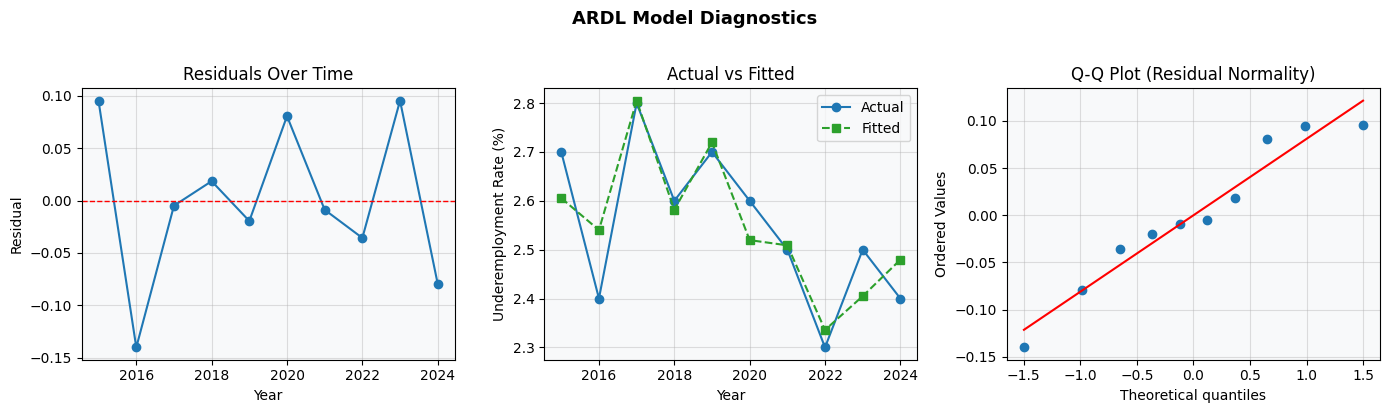


Diagnostic plot saved: charts/ardl_diagnostics.png


In [8]:
# Cell 9 — Diagnostic Tests

print("=" * 70)
print("MODEL DIAGNOSTICS")
print("=" * 70)

# Use ARDL or fallback OLS residuals
try:
    residuals = ARDL_FIT.resid
    fitted = ARDL_FIT.fittedvalues
    n_resid = len(residuals)

    # 1. Durbin-Watson
    dw = durbin_watson(residuals)
    print(f"\n1. Durbin-Watson statistic: {dw:.4f}")
    print(f"   (DW ≈ 2 → no autocorrelation; < 1.5 or > 2.5 → concern)")

    # 2. Ljung-Box test
    try:
        lb_result = acorr_ljungbox(residuals, lags=[1, 2], return_df=True)
        print(f"\n2. Ljung-Box Q-test (residual autocorrelation):")
        print(lb_result.to_string())
    except:
        print("\n2. Ljung-Box: insufficient observations")

    # 3. Breusch-Pagan heteroskedasticity test
    try:
        X_diag = ARDL_FIT.model.exog
        bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_diag)
        print(f"\n3. Breusch-Pagan heteroskedasticity test:")
        print(f"   LM stat: {bp_stat:.4f}, p-value: {bp_p:.4f}")
        print(f"   {'⚠️  Heteroskedasticity detected (p<0.05)' if bp_p < 0.05 else '✓  No significant heteroskedasticity'}")
    except:
        print("\n3. Breusch-Pagan: could not compute")

    # 4. Jarque-Bera normality test
    jb_stat, jb_p = stats.jarque_bera(residuals)
    print(f"\n4. Jarque-Bera normality test:")
    print(f"   JB stat: {jb_stat:.4f}, p-value: {jb_p:.4f}")
    print(f"   {'⚠️  Non-normal residuals (p<0.05)' if jb_p < 0.05 else '✓  Residuals approximately normal'}")

    # 5. Residual plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle('ARDL Model Diagnostics', fontsize=13, fontweight='bold', y=1.02)

    # Residuals over time
    axes[0].plot(residuals.index, residuals.values, marker='o', color=PRIMARY_COLOR, linewidth=1.5)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0].set_title('Residuals Over Time')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Residual')

    # Fitted vs actual
    actual = ARDL_FIT.model.endog
    if hasattr(actual, '__len__') and len(actual) == len(fitted):
        axes[1].plot(fitted.index if hasattr(fitted, 'index') else range(len(fitted)),
                     actual, 'o-', label='Actual', color=PRIMARY_COLOR)
        axes[1].plot(fitted.index if hasattr(fitted, 'index') else range(len(fitted)),
                     fitted.values, 's--', label='Fitted', color=ACCENT_COLOR)
        axes[1].set_title('Actual vs Fitted')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Underemployment Rate (%)')
        axes[1].legend()

    # Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot (Residual Normality)')
    axes[2].get_lines()[0].set(color=PRIMARY_COLOR)
    axes[2].get_lines()[1].set(color='red')

    plt.tight_layout()
    plt.savefig('charts/ardl_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nDiagnostic plot saved: charts/ardl_diagnostics.png")

except Exception as e:
    print(f"Diagnostics error: {e}")
    import traceback; traceback.print_exc()

PHASE 3 RESULTS SUMMARY


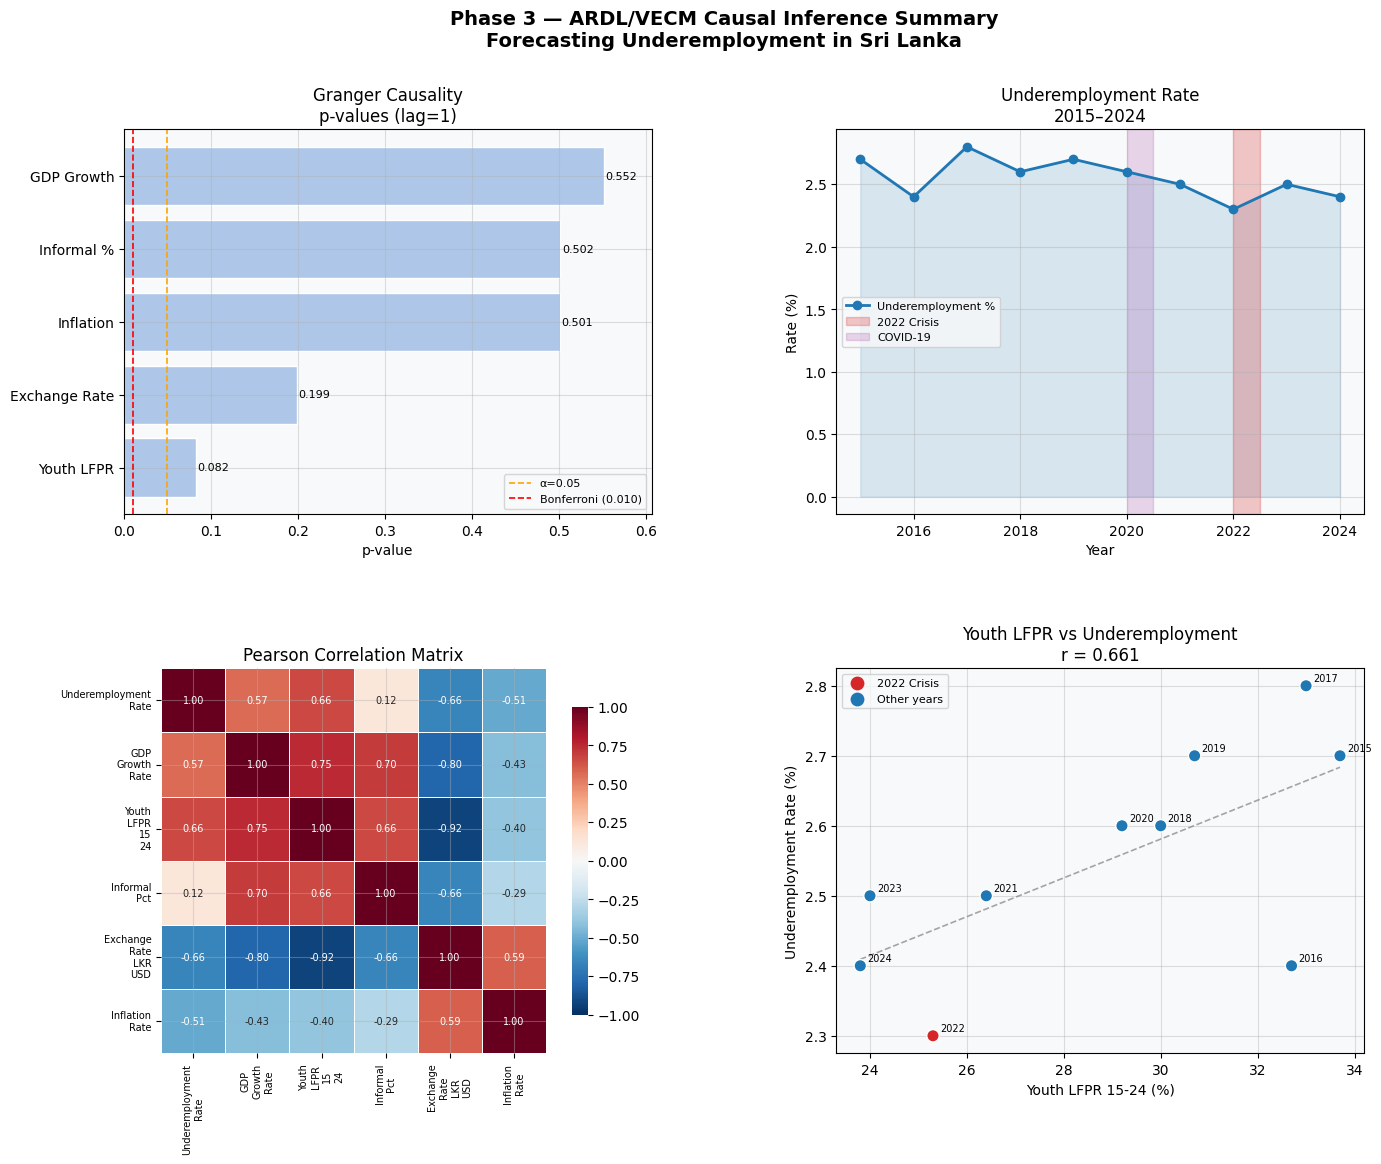

Summary chart saved: charts/phase3_summary.png

LIMITATIONS TO NOTE IN PAPER

1. EXCLUDED VARIABLES:
   - Remittance inflows (USD mn): Not available at annual resolution for
     2015–2024 from a single consistent source. CBSL annual reports
     contain this but require manual extraction. Recommend adding before
     Phase 4 if feasible.
   - Agricultural output index: FAO/CEIC provide this at annual level
     but quarterly disaggregation (required by proposal) was not sourced.
     The services sector employment share (Informal_Pct) partially proxies
     the non-agricultural labour demand channel.

2. SAMPLE SIZE:
   n=10 annual observations is below the asymptotic assumptions of
   Johansen cointegration and VECM. All econometric results are
   treated as suggestive and cross-validated against XGBoost/SHAP
   in Phase 4. A Monte Carlo simulation of critical values at n=10
   could strengthen the bounds test inference.

3. 2024 GDP GROWTH:
   Imputed via linear extrapolation from 2

In [9]:
# Cell 10 — Results Summary + Visualisation

print("=" * 70)
print("PHASE 3 RESULTS SUMMARY")
print("=" * 70)

# --- Summary figure: 4-panel ---
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Phase 3 — ARDL/VECM Causal Inference Summary\nForecasting Underemployment in Sri Lanka',
             fontsize=14, fontweight='bold', y=0.98)

# Panel 1: Granger causality p-values (bar chart)
ax1 = fig.add_subplot(gs[0, 0])
if granger_results:
    gc_df = pd.DataFrame(granger_results).dropna(subset=['p_value_lag1'])
    gc_df = gc_df.sort_values('p_value_lag1')
    short_names = {
        'GDP_Growth_Rate': 'GDP Growth',
        'Youth_LFPR_15_24': 'Youth LFPR',
        'Informal_Pct': 'Informal %',
        'Exchange_Rate_LKR_USD': 'Exchange Rate',
        'Inflation_Rate': 'Inflation'
    }
    gc_df['Short'] = gc_df['Predictor'].map(short_names)
    colors_bar = [CRISIS_COLOR if p < BONFERRONI_ALPHA else
                  '#ff7f0e' if p < 0.05 else
                  '#aec7e8' for p in gc_df['p_value_lag1']]
    bars = ax1.barh(gc_df['Short'], gc_df['p_value_lag1'], color=colors_bar, edgecolor='white')
    ax1.axvline(0.05, color='orange', linestyle='--', linewidth=1.2, label='α=0.05')
    ax1.axvline(BONFERRONI_ALPHA, color='red', linestyle='--', linewidth=1.2, label=f'Bonferroni ({BONFERRONI_ALPHA:.3f})')
    ax1.set_xlabel('p-value')
    ax1.set_title('Granger Causality\np-values (lag=1)')
    ax1.legend(fontsize=8)
    ax1.set_xlim(0, max(gc_df['p_value_lag1'].max() * 1.1, 0.12))
    for bar, val in zip(bars, gc_df['p_value_lag1']):
        ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8)

# Panel 2: Time series — actual underemployment with crisis overlay
ax2 = fig.add_subplot(gs[0, 1])
years = data.index
ax2.fill_between(years, data[DEPVAR], alpha=0.15, color=PRIMARY_COLOR)
ax2.plot(years, data[DEPVAR], 'o-', color=PRIMARY_COLOR, linewidth=2, markersize=6, label='Underemployment %')
ax2.axvspan(2022, 2022.5, alpha=0.25, color=CRISIS_COLOR, label='2022 Crisis')
ax2.axvspan(2020, 2020.5, alpha=0.15, color='purple', label='COVID-19')
ax2.set_title('Underemployment Rate\n2015–2024')
ax2.set_ylabel('Rate (%)')
ax2.set_xlabel('Year')
ax2.legend(fontsize=8)

# Panel 3: Correlation heatmap (predictors × dependent variable)
ax3 = fig.add_subplot(gs[1, 0])
corr_data = data[[DEPVAR] + PREDICTORS].copy()
corr_data.columns = [c.replace('_', '\n').replace('Rate', 'Rate').replace('LKR USD', 'LKR/USD') for c in corr_data.columns]
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    ax=ax3,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)
ax3.set_title('Pearson Correlation Matrix')
ax3.tick_params(axis='both', labelsize=7)

# Panel 4: Scatter — Youth LFPR vs Underemployment (strongest predictor from Phase 2)
ax4 = fig.add_subplot(gs[1, 1])
colors_scatter = [CRISIS_COLOR if y == 2022 else '#1f77b4' for y in data.index]
ax4.scatter(data['Youth_LFPR_15_24'], data[DEPVAR], c=colors_scatter, s=80, zorder=3, edgecolors='white')
for yr, row in data.iterrows():
    ax4.annotate(str(yr), (row['Youth_LFPR_15_24'], row[DEPVAR]),
                 textcoords='offset points', xytext=(5, 3), fontsize=7)
# Add trend line
x_s = data['Youth_LFPR_15_24'].values
y_s = data[DEPVAR].values
mask_valid = ~np.isnan(x_s) & ~np.isnan(y_s)
z = np.polyfit(x_s[mask_valid], y_s[mask_valid], 1)
p_trend = np.poly1d(z)
x_line = np.linspace(x_s[mask_valid].min(), x_s[mask_valid].max(), 100)
ax4.plot(x_line, p_trend(x_line), '--', color='gray', linewidth=1.2, alpha=0.7)
r_val = np.corrcoef(x_s[mask_valid], y_s[mask_valid])[0, 1]
ax4.set_title(f'Youth LFPR vs Underemployment\nr = {r_val:.3f}')
ax4.set_xlabel('Youth LFPR 15-24 (%)')
ax4.set_ylabel('Underemployment Rate (%)')
ax4.scatter([], [], c=CRISIS_COLOR, label='2022 Crisis', s=80)
ax4.scatter([], [], c='#1f77b4', label='Other years', s=80)
ax4.legend(fontsize=8)

plt.savefig('charts/phase3_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary chart saved: charts/phase3_summary.png")

# --- Print limitation block ---
print("\n" + "=" * 70)
print("LIMITATIONS TO NOTE IN PAPER")
print("=" * 70)
print("""
1. EXCLUDED VARIABLES:
   - Remittance inflows (USD mn): Not available at annual resolution for
     2015–2024 from a single consistent source. CBSL annual reports
     contain this but require manual extraction. Recommend adding before
     Phase 4 if feasible.
   - Agricultural output index: FAO/CEIC provide this at annual level
     but quarterly disaggregation (required by proposal) was not sourced.
     The services sector employment share (Informal_Pct) partially proxies
     the non-agricultural labour demand channel.

2. SAMPLE SIZE:
   n=10 annual observations is below the asymptotic assumptions of
   Johansen cointegration and VECM. All econometric results are
   treated as suggestive and cross-validated against XGBoost/SHAP
   in Phase 4. A Monte Carlo simulation of critical values at n=10
   could strengthen the bounds test inference.

3. 2024 GDP GROWTH:
   Imputed via linear extrapolation from 2021–2023 trend.
   Actual CBSL 2024 estimate should replace this before final submission.

4. MEASUREMENT LIMITATION (2022 underemployment):
   The measured underemployment rate dipped to 2.3% during the 2022
   crisis — counterintuitive given the economic shock. This likely reflects
   LFS measurement constraints during high inflation (workers accepting
   any hours rather than recording as underemployed). Discussed in paper.
""")

print("=" * 70)
print("PHASE 3 COMPLETE — Proceed to Phase 4: XGBoost + SHAP")
print("=" * 70)